In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import warnings
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, auc
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import requests
import time
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
data_path = os.path.dirname(os.getcwd()) + '/Data'
figure_path = os.path.dirname(os.getcwd()) + '/Figures'

# Discovery data

In [4]:
# Load and preprocess Olink proteomics data
olink = pd.read_csv(data_path + '/raw/olink.csv', delimiter=';')
olink = olink[['SampleID', 'Assay', 'NPX']]  # Keep only essential columns
print('Olink data - number of unique Sample IDs', len(set(olink['SampleID'])))

# Pivot data from long to wide format (samples as rows, proteins as columns)
pivoted_data = olink.pivot_table(index='SampleID', columns='Assay', values='NPX', aggfunc='mean')
pivoted_data.columns.name = None
pivoted_data = pivoted_data.reset_index()

# Load sample phenotype information
pheno = pd.read_excel(data_path + '/raw/MASTER_PHENO_FILE_AML_ALL_controls_20260122.xlsx')

# Clean immunopheno column - replace missing values with 'CTRL' (control)
pheno['immunopheno'] = pheno['immunopheno'].fillna('CTRL').replace(['nan', 'NaN', None], 'CTRL')
pheno['SampleID'] = pheno['sample_id']
print('Pheno data - number of unique Sample IDs', len(set(pheno['SampleID'])))
pheno = pheno[['SampleID', 'public_id', 'immunopheno', 'Subtype']]

# Merge proteomics data with phenotype information
merged = pd.merge(pivoted_data, pheno, on='SampleID', how='inner')

# Remove specific patients (quality control exclusions)
removed_patients = ['AML_101','AML_139', 'ALL_920', 'K-023']
#removed_patients = ['AML_101','AML_139', 'K-023'] # keep ALL_920 to check the values later
final_df = merged[~merged['public_id'].isin(removed_patients)]
print('Merged data - number of unique Sample IDs', len(set(final_df['SampleID'])))

print('----------')
print('Sample distribution across immunophenotypes')
counts = final_df['immunopheno'].value_counts()
print(counts)

Olink data - number of unique Sample IDs 92
Pheno data - number of unique Sample IDs 88
Merged data - number of unique Sample IDs 84
----------
Sample distribution across immunophenotypes
immunopheno
B-ALL    45
AML      19
CTRL     11
T-ALL     9
Name: count, dtype: int64


In [5]:
discovery_data_olink = final_df.copy()
discovery_data_olink = discovery_data_olink[discovery_data_olink['immunopheno'] == 'B-ALL']
discovery_data_olink['Subtype'] = discovery_data_olink['Subtype'].replace('t1221', 'ETV6::RUNX1')

# Validation data (Olink)

In [6]:
pb = pd.read_csv(data_path + '/results/validation/pb_olink.csv', delimiter=',')
bm = pd.read_csv(data_path + '/results/validation/bm_olink.csv', delimiter=',')

# ETV6::RUNX1 vs HEH

In [7]:
# Read all three datasets
df_discovery = pd.read_excel(data_path + '/results/HeH_vs_ETV6_RUNX1_results.xlsx')  # Original discovery
df_validation_blood = pd.read_csv(data_path + '/results/validation/pb_npx_norm_results.csv')  # Blood validation
df_validation_bone_marrow = pd.read_csv(data_path + '/results/validation/bm_npx_norm_results.csv')  # Bone marrow validation

# Add dataset labels
df_discovery['Dataset'] = 'Discovery'
df_validation_blood['Dataset'] = 'Blood Validation'
df_validation_bone_marrow['Dataset'] = 'Bone Marrow Validation'

Data loaded successfully!
Discovery proteins: 19
Blood validation proteins: 19
Bone marrow validation proteins: 19

Discovery significant proteins (adj p < 0.05): 19
Blood validation significant proteins (adj p < 0.05): 10
Bone marrow validation significant proteins (adj p < 0.05): 15


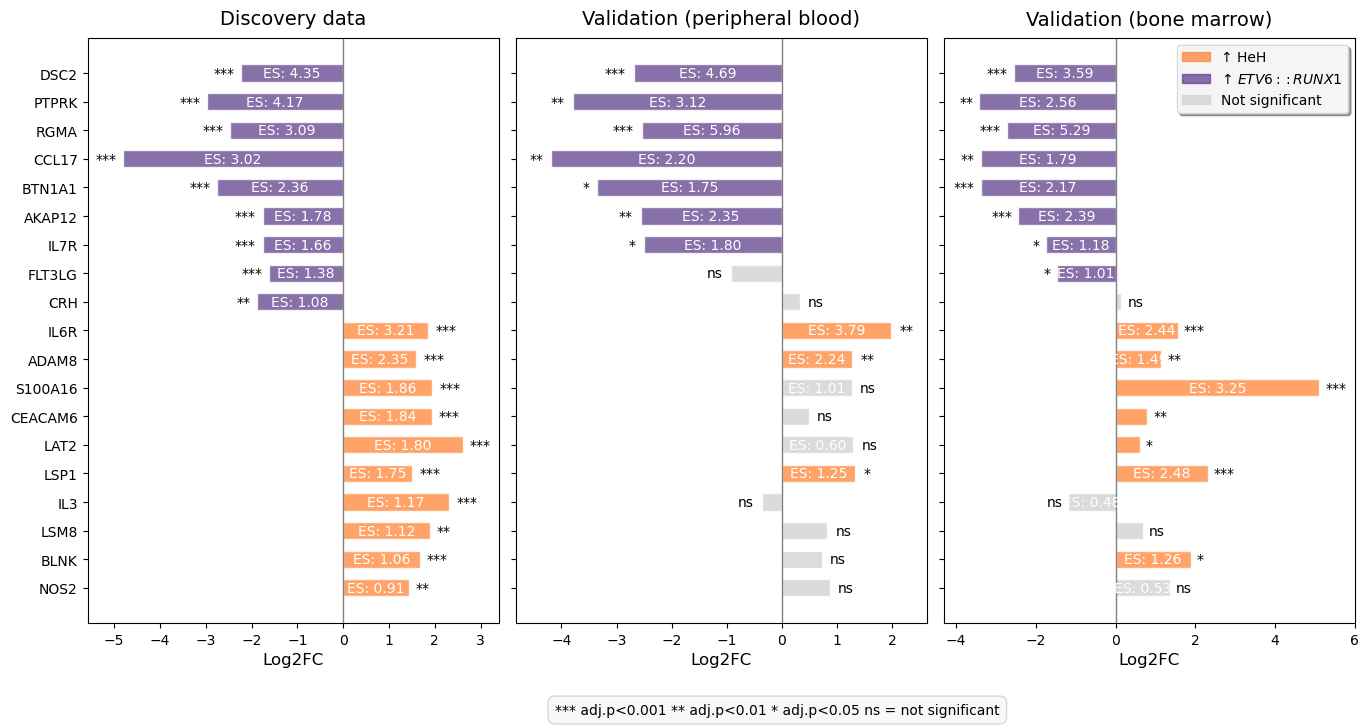

In [8]:
# Set style for publication-ready figures
plt.style.use('default')
sns.set_palette("husl")

# Create significance categories for visualization
def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

df_discovery['Significance'] = df_discovery['Adjusted P-value'].apply(get_significance_stars)
df_validation_blood['Significance'] = df_validation_blood['Adjusted P-value'].apply(get_significance_stars)
df_validation_bone_marrow['Significance'] = df_validation_bone_marrow['Adjusted P-value'].apply(get_significance_stars)

# Updated colors - Purple for ETV6::RUNX1, Orange for HeH
def get_color(log2fc, adj_pval):
    if adj_pval >= 0.05:
        return '#D3D3D3'    # Light gray for not significant
    elif log2fc > 0:
        return '#FF8C42'    # Orange for HeH upregulated
    else:
        return '#6A4C93'    # Purple for ETV6::RUNX1 upregulated

df_discovery['Color'] = df_discovery.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)
df_validation_blood['Color'] = df_validation_blood.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)
df_validation_bone_marrow['Color'] = df_validation_bone_marrow.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)

print("Data loaded successfully!")
print(f"Discovery proteins: {len(df_discovery)}")
print(f"Blood validation proteins: {len(df_validation_blood)}")
print(f"Bone marrow validation proteins: {len(df_validation_bone_marrow)}")
print("\nDiscovery significant proteins (adj p < 0.05):", sum(df_discovery['Adjusted P-value'] < 0.05))
print("Blood validation significant proteins (adj p < 0.05):", sum(df_validation_blood['Adjusted P-value'] < 0.05))
print("Bone marrow validation significant proteins (adj p < 0.05):", sum(df_validation_bone_marrow['Adjusted P-value'] < 0.05))

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

# Get unique proteins and sort by discovery effect size
#protein_order = df_discovery.sort_values('Effect size', ascending=True)['Protein/gene'].values

# Sort by sign of Log2FC first (negative/HeH first, then positive/ETV6::RUNX1), 
# then by magnitude within each group
df_discovery_sorted = df_discovery.copy()
df_discovery_sorted['Sign'] = (df_discovery_sorted['Log2FC'] > 0).astype(int)
protein_order = df_discovery_sorted.sort_values(['Sign', 'Effect size'], ascending=[False, True])['Protein/gene'].values

y_pos = np.arange(len(protein_order))

# Plot Discovery data (left panel)
discovery_data = df_discovery.set_index('Protein/gene').loc[protein_order]
bars1 = ax1.barh(y_pos, discovery_data['Log2FC'], height=0.6, 
                 color=discovery_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for discovery
for i, (protein, row) in enumerate(discovery_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax1.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)
    
    # Effect size text
    if abs(row['Log2FC']) > 1:
        ax1.text(row['Log2FC']/2, i, f'ES: {row["Effect size"]:.2f}', 
                 ha='center', va='center', 
                 fontsize=10, color='white')

# Plot Blood Validation data (middle panel)
blood_validation_data = df_validation_blood.set_index('Protein/gene').loc[protein_order]
bars2 = ax2.barh(y_pos, blood_validation_data['Log2FC'], height=0.6, 
                 color=blood_validation_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for blood validation
for i, (protein, row) in enumerate(blood_validation_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax2.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)
    
    # Effect size text
    if abs(row['Log2FC']) > 1:
        ax2.text(row['Log2FC']/2, i, f'ES: {row["Effect size"]:.2f}', 
                 ha='center', va='center', 
                 fontsize=10, color='white')

# Plot Bone Marrow Validation data (right panel)
bone_marrow_validation_data = df_validation_bone_marrow.set_index('Protein/gene').loc[protein_order]
bars3 = ax3.barh(y_pos, bone_marrow_validation_data['Log2FC'], height=0.6, 
                 color=bone_marrow_validation_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for bone marrow validation
for i, (protein, row) in enumerate(bone_marrow_validation_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax3.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)
    
    # Effect size text
    if abs(row['Log2FC']) > 1:
        ax3.text(row['Log2FC']/2, i, f'ES: {row["Effect size"]:.2f}', 
                 ha='center', va='center', 
                 fontsize=10, color='white')

# Customize all plots 
for ax in [ax1, ax2, ax3]:
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=1)
    ax.set_xlabel('Log2FC', fontsize=12)
    # Add padding to x-axis limits to prevent stars from covering the line
    xlim = ax.get_xlim()
    padding = (xlim[1] - xlim[0]) * 0.05
    ax.set_xlim(xlim[0] - padding, xlim[1] + padding)

# Set y-axis labels only on left plot
ax1.set_yticks(y_pos)
ax1.set_yticklabels(protein_order)
ax1.set_ylabel('', fontsize=12)

# Titles
ax1.set_title('Discovery data', fontsize=14, pad=10)
ax2.set_title('Validation (peripheral blood)', fontsize=14, pad=10)
ax3.set_title('Validation (bone marrow)', fontsize=14, pad=10)

# Overall title
fig.suptitle('', fontsize=16, y=0.95)

# Create improved legend
legend_elements = [
    mpatches.Patch(color='#FF8C42', alpha=0.8, label='↑ HeH'),
    mpatches.Patch(color='#6A4C93', alpha=0.8, label=r'↑ $\mathit{ETV6::RUNX1}$'),
    mpatches.Patch(color='#D3D3D3', alpha=0.8, label='Not significant')
]

# Place legend in a better position with improved styling
legend = ax3.legend(handles=legend_elements,  
                   fancybox=True,
                   shadow=True,
                   fontsize=10,
                   title='',
                   title_fontsize=10)

# Style the legend frame
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')
legend.get_frame().set_alpha(0.9)

# Add significance legend with better styling
significance_text = '*** adj.p<0.001 ** adj.p<0.01 * adj.p<0.05 ns = not significant'
fig.text(0.35, -0.05, significance_text, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', 
                  facecolor='#F8F8F8', 
                  edgecolor='lightgray', 
                  alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, right=0.85)
plt.savefig(figure_path + '/validation_v2/forest_plots.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_path + '/validation_v2/forest_plots.pdf', dpi=300, bbox_inches='tight')
plt.savefig(figure_path + '/validation_v2/forest_plots.svg', dpi=300, bbox_inches='tight')
plt.show()

# Remove effect sizes

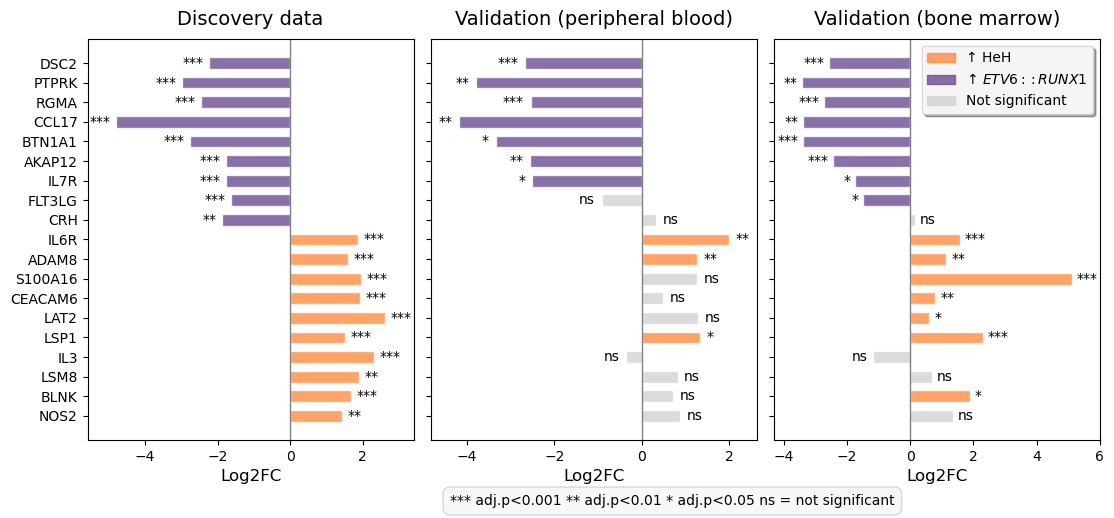

In [17]:
# Set style for publication-ready figures
plt.style.use('default')
sns.set_palette("husl")

# Create significance categories for visualization
def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

df_discovery['Significance'] = df_discovery['Adjusted P-value'].apply(get_significance_stars)
df_validation_blood['Significance'] = df_validation_blood['Adjusted P-value'].apply(get_significance_stars)
df_validation_bone_marrow['Significance'] = df_validation_bone_marrow['Adjusted P-value'].apply(get_significance_stars)

# Updated colors - Purple for ETV6::RUNX1, Orange for HeH
def get_color(log2fc, adj_pval):
    if adj_pval >= 0.05:
        return '#D3D3D3'    # Light gray for not significant
    elif log2fc > 0:
        return '#FF8C42'    # Orange for HeH upregulated
    else:
        return '#6A4C93'    # Purple for ETV6::RUNX1 upregulated

df_discovery['Color'] = df_discovery.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)
df_validation_blood['Color'] = df_validation_blood.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)
df_validation_bone_marrow['Color'] = df_validation_bone_marrow.apply(lambda row: get_color(row['Log2FC'], row['Adjusted P-value']), axis=1)


# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

# Get unique proteins and sort by discovery effect size
#protein_order = df_discovery.sort_values('Effect size', ascending=True)['Protein/gene'].values

# Sort by sign of Log2FC first (negative/HeH first, then positive/ETV6::RUNX1), 
# then by magnitude within each group
df_discovery_sorted = df_discovery.copy()
df_discovery_sorted['Sign'] = (df_discovery_sorted['Log2FC'] > 0).astype(int)
protein_order = df_discovery_sorted.sort_values(['Sign', 'Effect size'], ascending=[False, True])['Protein/gene'].values

y_pos = np.arange(len(protein_order))

# Plot Discovery data (left panel)
discovery_data = df_discovery.set_index('Protein/gene').loc[protein_order]
bars1 = ax1.barh(y_pos, discovery_data['Log2FC'], height=0.6, 
                 color=discovery_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for discovery
for i, (protein, row) in enumerate(discovery_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax1.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)
    

# Plot Blood Validation data (middle panel)
blood_validation_data = df_validation_blood.set_index('Protein/gene').loc[protein_order]
bars2 = ax2.barh(y_pos, blood_validation_data['Log2FC'], height=0.6, 
                 color=blood_validation_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for blood validation
for i, (protein, row) in enumerate(blood_validation_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax2.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)

# Plot Bone Marrow Validation data (right panel)
bone_marrow_validation_data = df_validation_bone_marrow.set_index('Protein/gene').loc[protein_order]
bars3 = ax3.barh(y_pos, bone_marrow_validation_data['Log2FC'], height=0.6, 
                 color=bone_marrow_validation_data['Color'], alpha=0.8, 
                 edgecolor='white', linewidth=1)

# Add significance stars and effect sizes for bone marrow validation
for i, (protein, row) in enumerate(bone_marrow_validation_data.iterrows()):
    # Significance stars
    x_pos = row['Log2FC'] + (0.15 if row['Log2FC'] > 0 else -0.15)
    ax3.text(x_pos, i, row['Significance'], 
             ha='left' if row['Log2FC'] > 0 else 'right', 
             va='center', fontsize=10)
    

# Customize all plots 
for ax in [ax1, ax2, ax3]:
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=1)
    ax.set_xlabel('Log2FC', fontsize=12)
    # Add padding to x-axis limits to prevent stars from covering the line
    xlim = ax.get_xlim()
    padding = (xlim[1] - xlim[0]) * 0.05
    ax.set_xlim(xlim[0] - padding, xlim[1] + padding)

# Set y-axis labels only on left plot
ax1.set_yticks(y_pos)
ax1.set_yticklabels(protein_order)
ax1.set_ylabel('', fontsize=12)

# Titles
ax1.set_title('Discovery data', fontsize=14, pad=10)
ax2.set_title('Validation (peripheral blood)', fontsize=14, pad=10)
ax3.set_title('Validation (bone marrow)', fontsize=14, pad=10)

# Overall title
fig.suptitle('', fontsize=16, y=0.95)

# Create improved legend
legend_elements = [
    mpatches.Patch(color='#FF8C42', alpha=0.8, label='↑ HeH'),
    mpatches.Patch(color='#6A4C93', alpha=0.8, label=r'↑ $\mathit{ETV6::RUNX1}$'),
    mpatches.Patch(color='#D3D3D3', alpha=0.8, label='Not significant')
]

# Place legend in a better position with improved styling
legend = ax3.legend(handles=legend_elements,  
                   fancybox=True,
                   shadow=True,
                   fontsize=10,
                   title='',
                   title_fontsize=10)

# Style the legend frame
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')
legend.get_frame().set_alpha(0.9)

# Add significance legend with better styling
significance_text = '*** adj.p<0.001 ** adj.p<0.01 * adj.p<0.05 ns = not significant'
fig.text(0.35, -0.05, significance_text, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', 
                  facecolor='#F8F8F8', 
                  edgecolor='lightgray', 
                  alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, right=0.85)
plt.savefig(figure_path + '/validation_v2/forest_plots_VR_simple.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Load Olink mapping file
olink = pd.read_csv(data_path + '/raw/olink.csv', delimiter=';')
id_mapping = olink[['Assay', 'UniProt']].drop_duplicates()

# Create a dictionary for quick lookup
gene_to_uniprot = dict(zip(id_mapping['Assay'], id_mapping['UniProt']))

# Simple function to wrap long protein names
def wrap_protein_name(protein_name, max_length=30):
    """Break long protein names into two lines"""
    if len(protein_name) <= max_length:
        return protein_name
    
    # Find a good break point (space closest to middle)
    words = protein_name.split()
    if len(words) > 1:
        mid_point = len(protein_name) // 2
        best_break = 0
        best_distance = float('inf')
        
        current_pos = 0
        for i, word in enumerate(words):
            current_pos += len(word)
            distance = abs(current_pos - mid_point)
            if distance < best_distance:
                best_distance = distance
                best_break = i
            current_pos += 1  # for space
        
        line1 = ' '.join(words[:best_break + 1])
        line2 = ' '.join(words[best_break + 1:])
        return f"{line1}\n{line2}"
    else:
        # Single word, just truncate
        return protein_name[:max_length-3] + "..."
    

# Function to fetch protein names from UniProt using UniProt IDs
def get_uniprot_info_by_id(gene_names, gene_to_uniprot_map):
    """Fetch protein names from UniProt using UniProt IDs"""
    protein_info = {}
    
    for gene in gene_names:
        # Get UniProt ID from mapping
        uniprot_id = gene_to_uniprot_map.get(gene)
        
        if not uniprot_id:
            print(f"No UniProt ID found for {gene}")
            protein_info[gene] = gene
            continue
            
        try:
            # Query UniProt API directly with UniProt ID
            url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}?format=json"
            response = requests.get(url)
            
            if response.status_code == 200:
                data = response.json()
                
                # Get recommended protein name
                if 'proteinDescription' in data:
                    try:
                        protein_name = data['proteinDescription']['recommendedName']['fullName']['value']
                    except:
                        # Try alternative name if recommended not available
                        try:
                            protein_name = data['proteinDescription']['alternativeNames'][0]['fullName']['value']
                        except:
                            protein_name = gene
                    
                    # Wrap long protein names
                    protein_name = wrap_protein_name(protein_name)
                    protein_info[gene] = protein_name
                else:
                    protein_info[gene] = gene
            else:
                print(f"Error fetching {uniprot_id} for {gene}: Status {response.status_code}")
                protein_info[gene] = gene
                
            # Be nice to the API
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Error fetching info for {gene} ({uniprot_id}): {e}")
            protein_info[gene] = gene
    
    return protein_info

### Prepare datasets (Olink and results files)

In [10]:
### Olink datasets
discovery = discovery_data_olink.copy()
validation_pb = pb.copy()
validation_bm = bm.copy()

# Load all results files - loaded earlier
# df_discovery = pd.read_excel(data_path + '/results/HeH_vs_ETV6_RUNX1_results.xlsx')
# df_validation_blood = pd.read_csv(data_path + '/results/validation/pb_npx_norm_results.csv')
# df_validation_bone_marrow = pd.read_csv(data_path + '/results/validation/bm_npx_norm_results.csv')

# top_3_proteins = df_discovery.nlargest(3, 'Effect size')['Protein/gene'].tolist()
# print(f"Top 3 proteins from discovery: {top_3_proteins}")
top_4_proteins = ['DSC2', 'PTPRK', 'IL6R', 'ADAM8']

# Fetch protein names using the existing function 
protein_names = get_uniprot_info_by_id(top_4_proteins, gene_to_uniprot)

# Pivot validation datasets from long to wide format
validation_pb_wide = validation_pb.pivot_table(
    index=['SampleID', 'Subtype'], 
    columns='Assay',
    values='NPX_norm'
).reset_index()

validation_bm_wide = validation_bm.pivot_table(
    index=['SampleID', 'Subtype'], 
    columns='Assay',
    values='NPX_norm'
).reset_index()


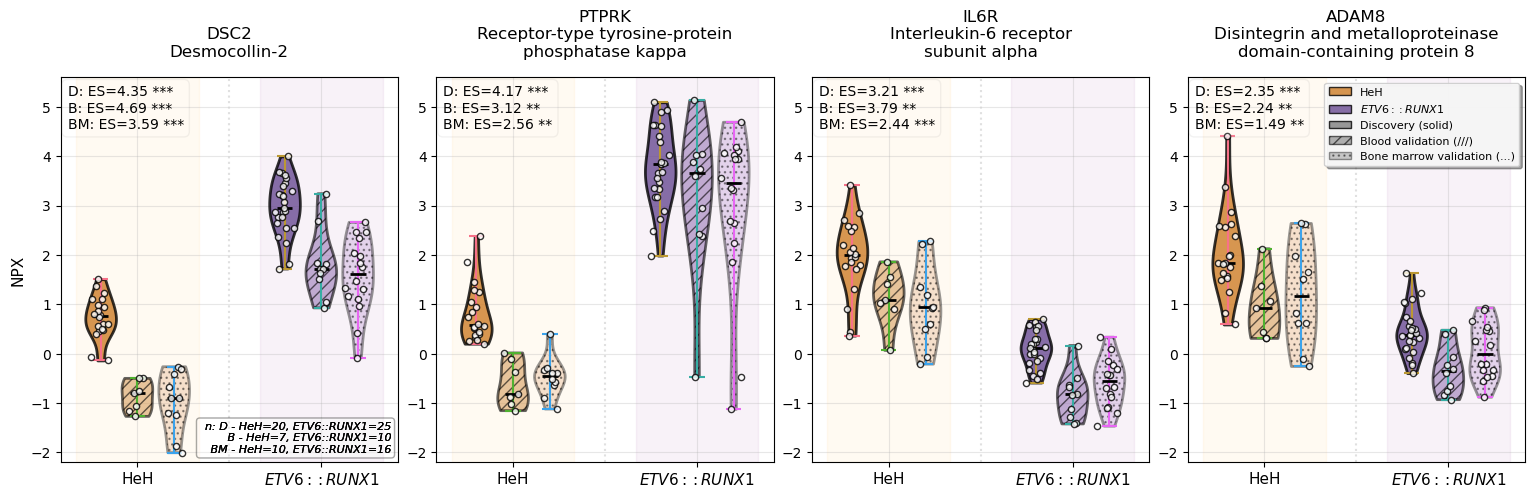

In [11]:
# Define colors for the three datasets
colors = {
    'HeH': {'discovery': "#CE7D27", 'blood': "#D79F60", 'bone_marrow': "#E8B892"},
    'ETV6::RUNX1': {'discovery': '#6A4C93', 'blood': '#9B7BB8', 'bone_marrow': '#C5A3D9'}
}

# Use different patterns for each dataset
alphas = {'discovery': 0.8, 'blood': 0.6, 'bone_marrow': 0.4}

# Create figure with larger size for better readability
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, protein in enumerate(top_4_proteins):
    ax = axes[i]
    
    # Prepare data for all three datasets
    # Discovery data
    disc_HeH = discovery[discovery['Subtype'] == 'HeH'][protein].dropna()
    disc_etv6 = discovery[discovery['Subtype'] == 'ETV6::RUNX1'][protein].dropna()
    
    # Blood validation data
    blood_HeH = validation_pb_wide[validation_pb_wide['Subtype'] == 'HeH'][protein].dropna()
    blood_etv6 = validation_pb_wide[validation_pb_wide['Subtype'] == 'ETV6::RUNX1'][protein].dropna()
    
    # Bone marrow validation data
    bm_HeH = validation_bm_wide[validation_bm_wide['Subtype'] == 'HeH'][protein].dropna()
    bm_etv6 = validation_bm_wide[validation_bm_wide['Subtype'] == 'ETV6::RUNX1'][protein].dropna()
    
    # Create positions for all datasets with proper spacing
    positions = {
        'HeH_discovery': 0.7,
        'HeH_blood': 1.0,
        'HeH_bone_marrow': 1.3,
        'ETV6_discovery': 2.2,
        'ETV6_blood': 2.5,
        'ETV6_bone_marrow': 2.8
    }
    
    # Plot Discovery violins (solid)
    parts1 = ax.violinplot([disc_HeH], positions=[positions['HeH_discovery']], 
                          widths=0.25, showmeans=False, showmedians=True)
    parts2 = ax.violinplot([disc_etv6], positions=[positions['ETV6_discovery']], 
                          widths=0.25, showmeans=False, showmedians=True)
    
    # Style discovery violins
    for pc in parts1['bodies']:
        pc.set_facecolor(colors['HeH']['discovery'])
        pc.set_alpha(alphas['discovery'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
    
    for pc in parts2['bodies']:
        pc.set_facecolor(colors['ETV6::RUNX1']['discovery'])
        pc.set_alpha(alphas['discovery'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
    
    # Plot Blood validation violins (hatched)
    parts3 = ax.violinplot([blood_HeH], positions=[positions['HeH_blood']], 
                          widths=0.25, showmeans=False, showmedians=True)
    parts4 = ax.violinplot([blood_etv6], positions=[positions['ETV6_blood']], 
                          widths=0.25, showmeans=False, showmedians=True)
    
    # Style blood validation violins
    for pc in parts3['bodies']:
        pc.set_facecolor(colors['HeH']['blood'])
        pc.set_alpha(alphas['blood'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
        pc.set_hatch('///')  # Diagonal hatching for blood validation
    
    for pc in parts4['bodies']:
        pc.set_facecolor(colors['ETV6::RUNX1']['blood'])
        pc.set_alpha(alphas['blood'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
        pc.set_hatch('///')  # Diagonal hatching for blood validation
    
    # Plot Bone marrow validation violins (dotted pattern)
    parts5 = ax.violinplot([bm_HeH], positions=[positions['HeH_bone_marrow']], 
                          widths=0.25, showmeans=False, showmedians=True)
    parts6 = ax.violinplot([bm_etv6], positions=[positions['ETV6_bone_marrow']], 
                          widths=0.25, showmeans=False, showmedians=True)
    
    # Style bone marrow validation violins
    for pc in parts5['bodies']:
        pc.set_facecolor(colors['HeH']['bone_marrow'])
        pc.set_alpha(alphas['bone_marrow'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
        pc.set_hatch('...')  # Dotted pattern for bone marrow validation
    
    for pc in parts6['bodies']:
        pc.set_facecolor(colors['ETV6::RUNX1']['bone_marrow'])
        pc.set_alpha(alphas['bone_marrow'])
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
        pc.set_hatch('...')  # Dotted pattern for bone marrow validation
    
    # Add individual patient dots with jitter
    np.random.seed(42)  # For reproducible jitter
    jitter_strength = 0.04
    
    # Discovery dots
    ax.scatter(np.random.normal(positions['HeH_discovery'], jitter_strength, len(disc_HeH)), 
               disc_HeH, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    ax.scatter(np.random.normal(positions['ETV6_discovery'], jitter_strength, len(disc_etv6)), 
               disc_etv6, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    
    # Blood validation dots
    ax.scatter(np.random.normal(positions['HeH_blood'], jitter_strength, len(blood_HeH)), 
               blood_HeH, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    ax.scatter(np.random.normal(positions['ETV6_blood'], jitter_strength, len(blood_etv6)), 
               blood_etv6, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    
    # Bone marrow validation dots
    ax.scatter(np.random.normal(positions['HeH_bone_marrow'], jitter_strength, len(bm_HeH)), 
               bm_HeH, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    ax.scatter(np.random.normal(positions['ETV6_bone_marrow'], jitter_strength, len(bm_etv6)), 
               bm_etv6, alpha=0.8, s=20, color='white', edgecolor='black', 
               linewidth=1, zorder=3)
    
    # # Highlight specific ER patients
    # highlight_ids = ['ALL_920', 'ALL_1428']
    # disc_subset = discovery[discovery['Subtype'].isin(['HeH', 'ETV6::RUNX1'])]
    # for sample_id in highlight_ids:
    #     sample_row = disc_subset[disc_subset['public_id'] == sample_id]
    #     if not sample_row.empty and protein in sample_row.columns:
    #         subtype = sample_row['Subtype'].values[0]
    #         value = sample_row[protein].values[0]
    #         if not np.isnan(value):
    #             pos = positions['HeH_discovery'] if subtype == 'HeH' else positions['ETV6_discovery']
    #             ax.scatter(pos, value, marker='*', s=300, color='red', 
    #                       edgecolor='darkred', linewidth=2, zorder=6)
    #             ax.annotate(sample_id, xy=(pos, value), xytext=(8, 0), 
    #                        textcoords='offset points', fontsize=8, 
    #                        color='darkred', fontweight='bold')
    
    # Get statistics from all datasets
    protein_row_discovery = df_discovery[df_discovery['Protein/gene'] == protein].iloc[0]
    protein_row_blood = df_validation_blood[df_validation_blood['Protein/gene'] == protein].iloc[0]
    protein_row_bm = df_validation_bone_marrow[df_validation_bone_marrow['Protein/gene'] == protein].iloc[0]
    
    # Discovery stats
    disc_effect = protein_row_discovery['Effect size']
    disc_p = protein_row_discovery['Adjusted P-value']
    disc_stars = get_significance_stars(disc_p)
    
    # Blood validation stats
    blood_effect = protein_row_blood['Effect size']
    blood_p = protein_row_blood['Adjusted P-value']
    blood_stars = get_significance_stars(blood_p)
    
    # Bone marrow validation stats
    bm_effect = protein_row_bm['Effect size']
    bm_p = protein_row_bm['Adjusted P-value']
    bm_stars = get_significance_stars(bm_p)
    
    # Add statistics text with better formatting for all three datasets
    stats_text = (f"D: ES={disc_effect:.2f} {disc_stars}\n"
                 f"B: ES={blood_effect:.2f} {blood_stars}\n"
                 f"BM: ES={bm_effect:.2f} {bm_stars}")
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            ha='left', va='top', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.1, edgecolor='gray'))
    
    # Add sample sizes once on the first subplot
    sample_text = (f"n: D - HeH={len(disc_HeH)}, ETV6::RUNX1={len(disc_etv6)}\n"
                f"   B - HeH={len(blood_HeH)}, ETV6::RUNX1={len(blood_etv6)}\n"
                f"   BM - HeH={len(bm_HeH)}, ETV6::RUNX1={len(bm_etv6)}")
    axes[0].text(0.98, 0.02, sample_text, transform=axes[0].transAxes, 
                ha='right', va='bottom', fontsize=8, style='italic',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.1))
    
    # Customize plot with protein names
    gene_name = protein
    protein_name = protein_names.get(protein, protein)
    
    # Create title with both gene and protein name
    title_text = f"{gene_name}\n{protein_name}"
    ax.set_title(title_text, fontsize=12, pad=15)
    
    # Set x-axis with three groups
    ax.set_xticks([1.0, 2.5])
    ax.set_xticklabels(['HeH', r'$\mathit{ETV6::RUNX1}$'], fontsize=11)
    ax.set_ylabel('NPX' if i == 0 else '', fontsize=11)
    
    # Add vertical separator line between groups
    ax.axvline(x=1.75, color='lightgray', linestyle=':', alpha=0.7, zorder=1)
    
    # Add subtle background rectangles to separate datasets within each group
    y_min, y_max = ax.get_ylim()
    # HeH group background
    ax.axvspan(0.5, 1.5, alpha=0.05, color='orange', zorder=0)
    # ETV6::RUNX1 group background  
    ax.axvspan(2.0, 3.0, alpha=0.05, color='purple', zorder=0)
    
    # Style median lines for better visibility
    all_parts = [parts1, parts2, parts3, parts4, parts5, parts6]
    for parts in all_parts:
        if 'cmedians' in parts:
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)
    
    # # Set y-axis limits with some padding
    # all_data = np.concatenate([disc_HeH, disc_etv6, blood_HeH, blood_etv6, bm_HeH, bm_etv6])
    # y_range = all_data.max() - all_data.min()
    # ax.set_ylim(all_data.min() - 0.1*y_range, all_data.max() + 0.1*y_range)

    # Set fixed y-axis limits
    ax.set_ylim(-2.2, 5.6)    
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

# Create comprehensive legend
legend_elements = [
    # Group colors (using discovery colors as reference)
    Patch(facecolor=colors['HeH']['discovery'], alpha=alphas['discovery'], 
          edgecolor='black', label='HeH'),
    Patch(facecolor=colors['ETV6::RUNX1']['discovery'], alpha=alphas['discovery'], 
          edgecolor='black', label=r'$\mathit{ETV6::RUNX1}$'),
    
    # Dataset distinction
    Patch(facecolor='gray', alpha=alphas['discovery'], 
          edgecolor='black', label='Discovery (solid)'),
    Patch(facecolor='gray', alpha=alphas['blood'], hatch='///',
          edgecolor='black', label='Blood validation (///)'),
    Patch(facecolor='gray', alpha=alphas['bone_marrow'], hatch='...',
          edgecolor='black', label='Bone marrow validation (...)')
]

# Add legend to the rightmost subplot
axes[3].legend(handles=legend_elements, 
               loc='upper right',
               fancybox=True, 
               shadow=True, 
               fontsize=8,
               framealpha=0.9)

# Add overall title
plt.suptitle('', fontsize=16)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, right=0.85, top=0.85)
plt.savefig(figure_path + '/validation_v2/top4_violins.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_path + '/validation_v2/top4_violins.pdf', dpi=300, bbox_inches='tight')
plt.savefig(figure_path + '/validation_v2/top4_violins.svg', dpi=300, bbox_inches='tight')
plt.show()

# Generate a combined file

In [12]:
# Read all three datasets
df_discovery = pd.read_excel(data_path + '/results/HeH_vs_ETV6_RUNX1_results.xlsx')
df_validation_blood = pd.read_csv(data_path + '/results/validation/pb_npx_norm_results.csv')
df_validation_bone_marrow = pd.read_csv(data_path + '/results/validation/bm_npx_norm_results.csv')

# Sort by sign of Log2FC first (negative/HeH first, then positive/ETV6::RUNX1), 
# then by magnitude within each group 
df_discovery_sorted = df_discovery.copy()
df_discovery_sorted['Sign'] = (df_discovery_sorted['Log2FC'] > 0).astype(int)
protein_order = df_discovery_sorted.sort_values(['Sign', 'Effect size'], ascending=[True, False])['Protein/gene'].values

# Select only the columns you want from each dataset
essential_cols = ['Protein/gene', 'Average HeH', 'Average ETV6::RUNX1', 'Log2FC', 'Effect size', 'Adjusted P-value']

df_disc_subset = df_discovery[essential_cols].copy()
df_blood_subset = df_validation_blood[essential_cols].copy()
df_bm_subset = df_validation_bone_marrow[essential_cols].copy()

# Rename columns with dataset suffix (except Protein/gene)
df_disc_subset.columns = ['Protein/gene'] + [f'{col}_Discovery' for col in essential_cols[1:]]
df_blood_subset.columns = ['Protein/gene'] + [f'{col}_Blood' for col in essential_cols[1:]]
df_bm_subset.columns = ['Protein/gene'] + [f'{col}_BoneMarrow' for col in essential_cols[1:]]

# Merge all three datasets
df_combined = df_disc_subset.merge(df_blood_subset, on='Protein/gene', how='outer')
df_combined = df_combined.merge(df_bm_subset, on='Protein/gene', how='outer')

# Round all numeric columns to 3 decimal places
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
df_combined[numeric_cols] = df_combined[numeric_cols].round(3)

# Sort by the protein order from the plot
df_combined['Sort_order'] = df_combined['Protein/gene'].map({protein: i for i, protein in enumerate(protein_order)})
df_combined_sorted = df_combined.sort_values('Sort_order').drop('Sort_order', axis=1)

# Reset index
df_combined_sorted = df_combined_sorted.reset_index(drop=True)

# Save to file
df_combined_sorted.to_csv(data_path + '/results/validation/combined_results_sorted.csv', index=False)
df_combined_sorted.to_excel(data_path + '/results/validation/combined_results_sorted.xlsx', index=False)